In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import geopandas as gpd
from matplotlib import pyplot as plt
import igraph as ig

import osm_nets
from osm_nets import pbf_extract

## Retrieve the `PBF` file

In [2]:
pbf_file = Path("albania-latest.osm.pbf")
if not pbf_file.is_file():
    urlretrieve("https://download.geofabrik.de/europe/albania-latest.osm.pbf", pbf_file)

## Load points and lines related to railways

In [3]:
stations = pbf_extract.extract_from_pbf(pbf_file, kind="railway", geom="points")
lines = pbf_extract.extract_from_pbf(pbf_file, kind="railway", geom="lines")

Running optimized geometry query...
Query completed! Retrieved 69 items.
Running optimized geometry query...
Query completed! Retrieved 785 items.


In [4]:
lines.to_file(pbf_file.with_suffix(".gpkg"), layer="ways", mode="w")
stations.to_file(pbf_file.with_suffix(".gpkg"), layer="points", mode="a")

[2026-07-27 11:47:55.100] INFO raw:723 - Created 785 records
[2026-07-27 11:47:55.130] INFO raw:723 - Created 69 records


## Tranform points and lines to a network

In [5]:
alb = gpd.read_file("./ne_110m_admin_0_countries.geojson").set_index("SOV_A3").loc["ALB", "geometry"]
graph = osm_nets.osm_railways(alb, pbf_file.with_suffix(".gpkg"))

[2026-07-27 11:47:56.498] INFO osm:82 - Area of size 3.1851627096790427
[2026-07-27 11:47:56.499] INFO osm:476 - Retrieving `LineString` data from OpenStreetMap.
[2026-07-27 11:47:56.522] WARNING osm:870 - Cleaning but not exploding. (`source` and `target` should be recomputed)
[2026-07-27 11:47:56.530] INFO osm:488 - Collected 784 edges.
[2026-07-27 11:47:56.531] INFO osm:788 - Splitting edges to connect when touching (using None workers).


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 784/784 [00:00<00:00, 16444.47it/s]

[2026-07-27 11:47:56.605] INFO osm:806 - Get nodes from edge boundaries
[2026-07-27 11:47:56.610] INFO osm:822 - Got 945 additional nodes
[2026-07-27 11:47:56.610] INFO osm:824 - Remove overlapping nodes. (Keep the first name)
[2026-07-27 11:47:56.689] INFO osm:116 - Getting stations from OpenStreetMap.
[2026-07-27 11:47:56.690] INFO osm:421 - Retrieving `Point` data from OpenStreetMap.
[2026-07-27 11:47:56.700] INFO osm:427 - Collected 207 nodes.
[2026-07-27 11:47:56.704] INFO osm:1199 - Aggregate nodes
[2026-07-27 11:47:56.704] INFO osm:2050 - Clustering 945 points


[2026-07-27 11:47:56.824] INFO osm:1201 - Aggregated nodes
[2026-07-27 11:47:56.825] INFO osm:1207 - Aggregated 945 nodes to 889
[2026-07-27 11:47:56.826] INFO osm:1088 - Adding 69 nodes to the edges within 300 meters


Add nodes (find edges):   0%|                                                                                 …

[2026-07-27 11:47:58.033] INFO osm:1199 - Aggregate nodes
[2026-07-27 11:47:58.034] INFO osm:2050 - Clustering 958 points
[2026-07-27 11:47:58.374] INFO osm:1201 - Aggregated nodes
[2026-07-27 11:47:58.376] INFO osm:1207 - Aggregated 958 nodes to 957
[2026-07-27 11:47:58.379] INFO osm:2050 - Clustering 69 points
[2026-07-27 11:47:58.479] INFO raw:723 - Created 1,097 records
[2026-07-27 11:47:58.500] INFO raw:723 - Created 957 records
[2026-07-27 11:47:58.528] INFO raw:723 - Created 1 records
[2026-07-27 11:47:58.569] INFO osm:1915 - Find shortest paths


Short paths: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 348.00it/s]

[2026-07-27 11:47:58.589] INFO osm:1917 - Check shortest paths



Check paths: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 903/903 [00:00<00:00, 1483.69it/s]

[2026-07-27 11:47:59.199] INFO osm:1929 - Remove unaccebtable paths.
[2026-07-27 11:47:59.199] INFO osm:1931 - Get ids


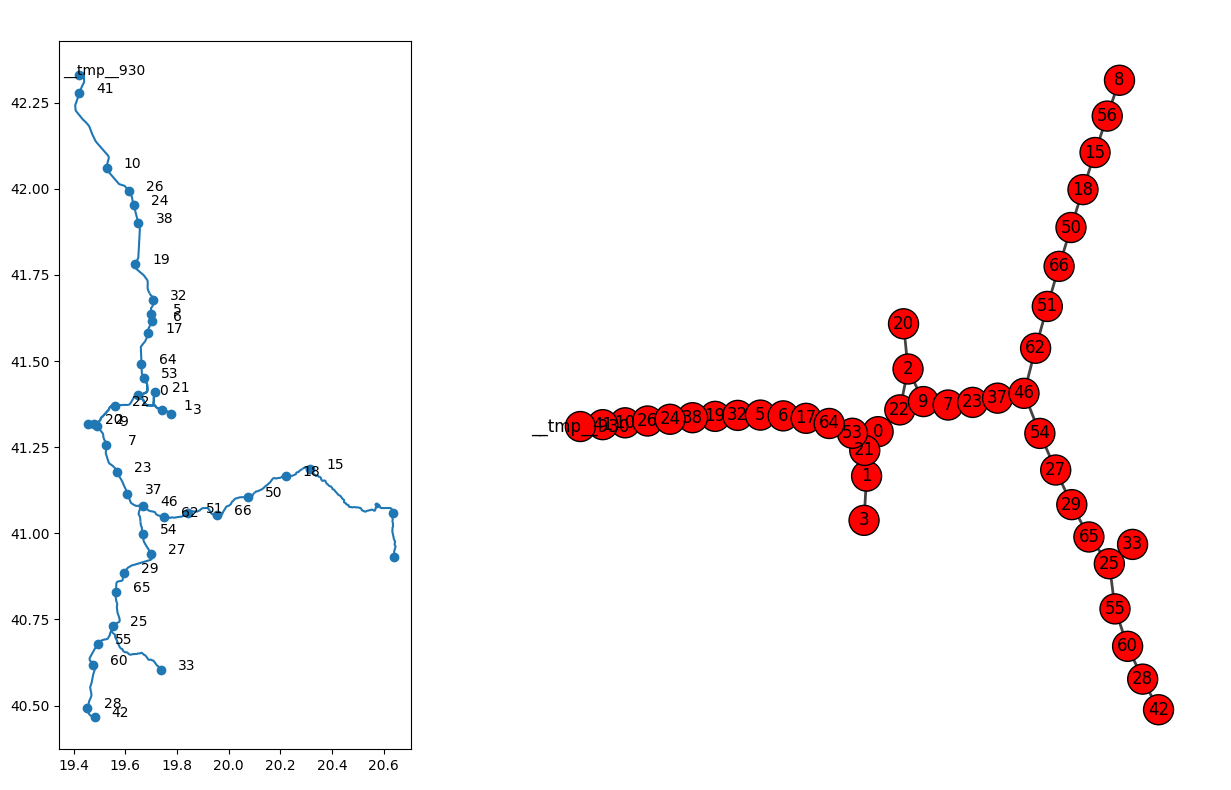

In [6]:
_, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15,10), width_ratios=[1,2])
graph.nodes.data.plot(ax=ax1)
graph.edges.data.plot(ax=ax1)
for idx, row in graph.nodes.data.iterrows():
    ax1.annotate(idx, xy=(row.geometry.x+0.1, row.geometry.y), ha='center', color='k')


ig.plot(graph.graph_ig(), ax=ax2, backend='matplotlib')